# 📌 1. Import Library


In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import joblib

# 📌 2. Load Dataset


In [48]:
df = pd.read_csv('dashboard/diabets_dataset_clean.csv')
X = df.drop(columns='diabetes', axis=1)
y = df['diabetes']


# 📊 Pie Chart Sebelum SMOTE


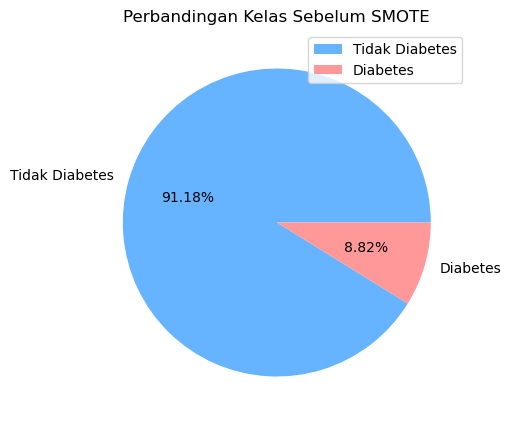

In [49]:
plt.figure(figsize=(5, 5))
plt.pie(df['diabetes'].value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', colors=['#66b3ff','#ff9999'])
plt.title('Perbandingan Kelas Sebelum SMOTE')
plt.legend()
plt.show()

# 📌 3. Feature Scaling


In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📌 4. Oversampling dengan SMOTE


In [51]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 📊 Pie Chart Setelah SMOTE


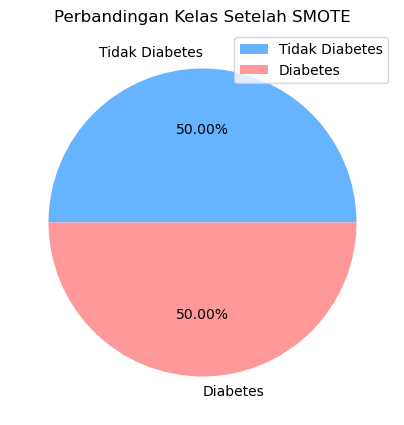

In [52]:
plt.figure(figsize=(5, 5))
plt.pie(pd.Series(y_resampled).value_counts().values, labels=['Tidak Diabetes', 'Diabetes'], autopct='%1.2f%%', colors=['#66b3ff','#ff9999'])
plt.title('Perbandingan Kelas Setelah SMOTE')
plt.legend()
plt.show()

# 📌 5. Train-test Split (setelah SMOTE)


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=2
)

# 📌 6. Model Training - SVM


In [ ]:
classifier = SVC(kernel='linear', random_state=42)
classifier.fit(X_train, y_train)

# 📌 7. Evaluation


In [ ]:
y_train_pred = classifier.predict(X_train)
y_test_pred = classifier.predict(X_test)

print("=== Evaluasi SVM dengan SMOTE ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred))

=== Evaluasi SVM dengan SMOTE ===
Train Accuracy: 0.8869758024268868
Test Accuracy: 0.8876404494382022
F1 Score: 0.8877812589005981
Recall: 0.8888952261449837

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     17533
           1       0.89      0.89      0.89     17533

    accuracy                           0.89     35066
   macro avg       0.89      0.89      0.89     35066
weighted avg       0.89      0.89      0.89     35066



# 📌 8. Confusion Matrix


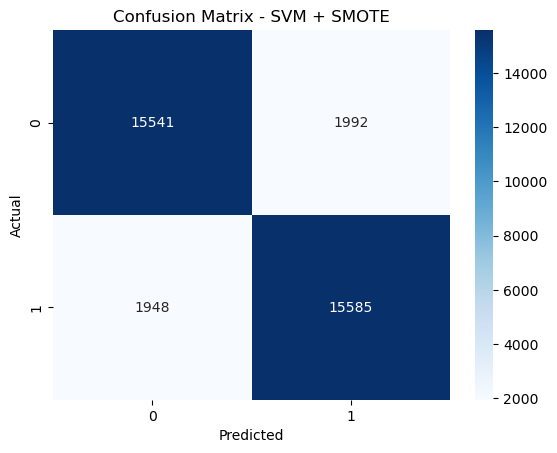

In [ ]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM + SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📌 9. Learning Curve


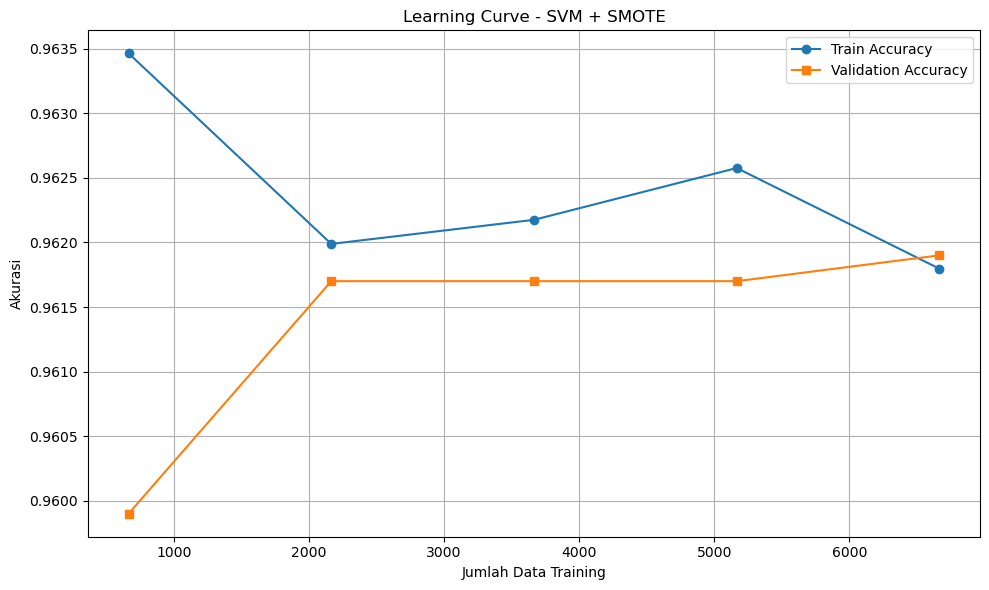

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    classifier, X_resampled, y_resampled,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Train Accuracy', marker='o')
plt.plot(train_sizes, test_mean, label='Validation Accuracy', marker='s')
plt.title('Learning Curve - SVM + SMOTE')
plt.xlabel('Jumlah Data Training')
plt.ylabel('Akurasi')
plt.grid(True)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 📌 10. Save Model dan Scaler


In [ ]:
joblib.dump(classifier, 'model/diabetes_model_svm_smote.sav')
joblib.dump(scaler, 'model/scaler_svm_smote.sav')

['model/scaler_svm_smote.sav']